# 05 — Poster Figures

Read CSVs from `results/` and produce poster-ready PNGs in `poster/`.

**Run notebooks 02, 03, 04 first** to generate the CSVs.

In [1]:
# === Kaggle / Colab setup (skip if running locally) ===
import os, subprocess, sys
from pathlib import Path

IS_KAGGLE = Path("/kaggle/working").exists()
IS_COLAB  = "google.colab" in sys.modules

if IS_KAGGLE or IS_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-r", "../requirements.txt"], check=True)
    # Kaggle ships pandas built against numpy 2.x, but spacy 3.7.5 pins numpy<2.
    # Force-reinstall pandas+numpy together so binary ABI matches.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "--force-reinstall", "--no-deps",
                    "numpy<2", "pandas>=2.0,<2.3"], check=True)
    subprocess.run([sys.executable, "-m", "spacy", "download",
                    "en_core_web_trf"], check=True)
    subprocess.run([sys.executable, "-m", "spacy", "download",
                    "ru_core_news_lg"], check=True)
    subprocess.run([sys.executable, "../scripts/download_data.py"],
                   check=True)
    print("Setup done.")
else:
    print("Local env detected — skipping cloud setup.")


Local env detected — skipping cloud setup.


In [2]:
import sys
sys.path.insert(0, "..")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.plotting import apply_poster_style, FAMILY

apply_poster_style()
POSTER = Path("../poster")
POSTER.mkdir(exist_ok=True)

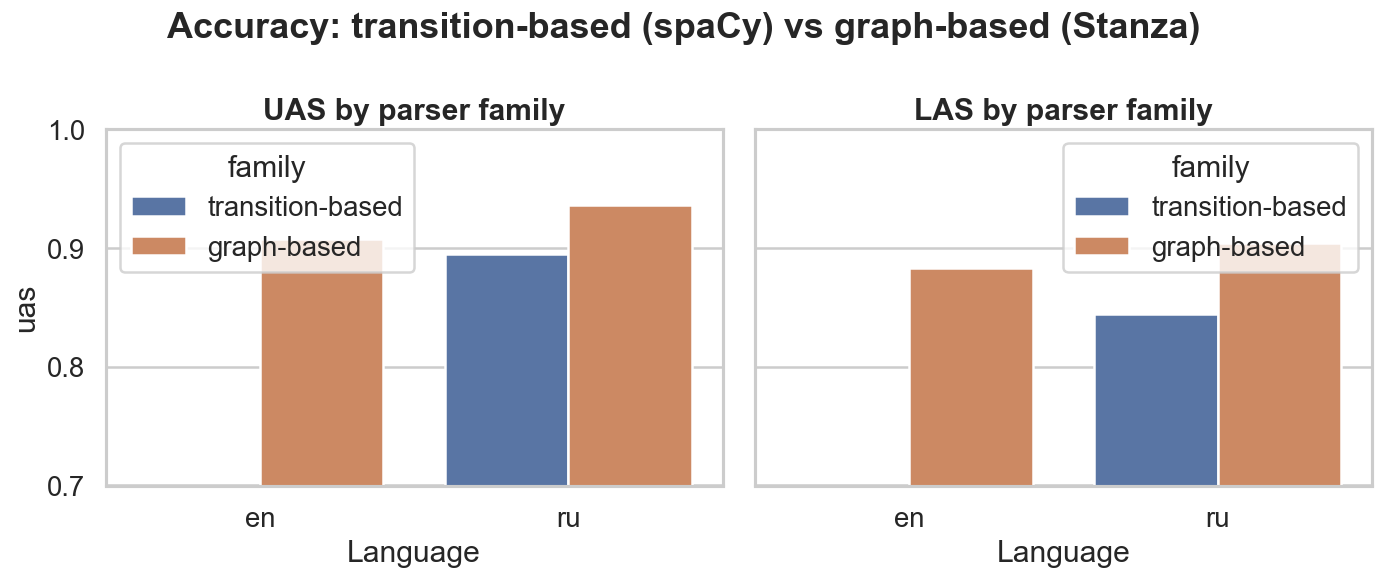

Saved fig_accuracy.png


In [4]:
# Figure 1: Core accuracy (LAS) by parser family
acc = pd.read_csv("../results/accuracy.csv")
acc["family"] = acc["parser"].map(FAMILY)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, metric, title in zip(axes, ["uas", "las"], ["UAS", "LAS"]):
    sns.barplot(acc, x="lang", y=metric, hue="family", ax=ax)
    ax.set_title(f"{title} by parser family")
    ax.set_ylim(0.7, 1.0)
    ax.set_xlabel("Language")
    ax.set_ylabel(metric)

fig.suptitle("Accuracy: transition-based (spaCy) vs graph-based (Stanza)", fontweight="bold")
fig.tight_layout()
fig.savefig(POSTER / "fig_accuracy.png")
plt.show()
print("Saved fig_accuracy.png")

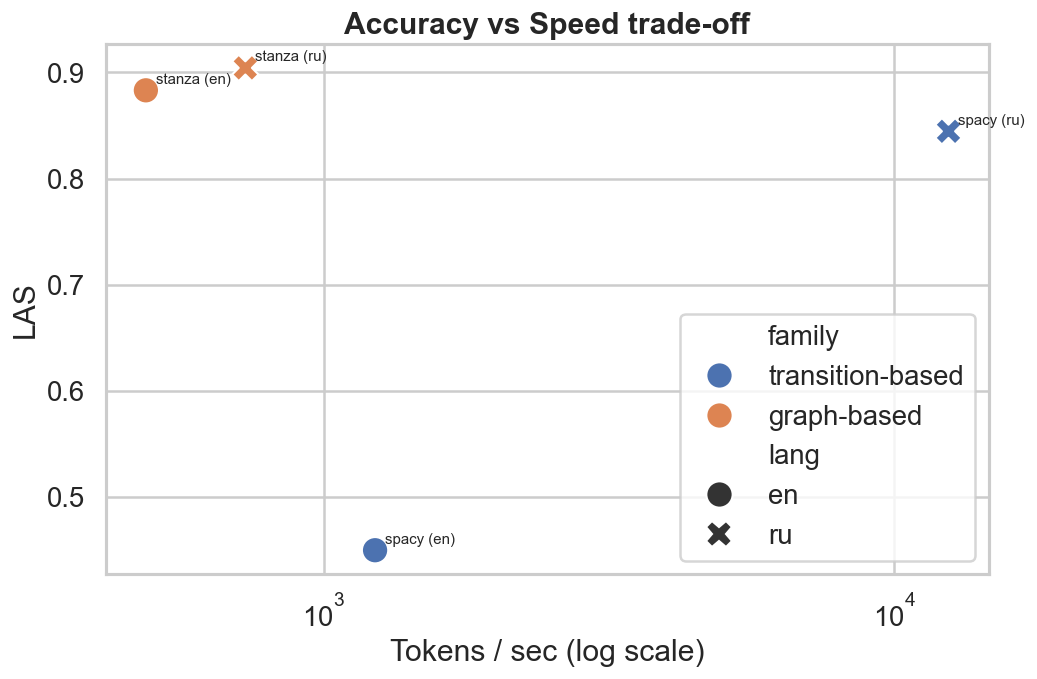

Saved fig_speed_vs_accuracy.png


In [5]:
# Figure 2: Speed vs accuracy trade-off scatter
perf = pd.read_csv("../results/performance.csv")
merged = acc.merge(perf, on=["lang", "parser"])
merged["family"] = merged["parser"].map(FAMILY)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    merged, x="tokens_per_sec_mean", y="las",
    hue="family", style="lang", s=250, ax=ax,
)
for _, r in merged.iterrows():
    ax.annotate(
        f"{r['parser'].split(':')[0]} ({r['lang']})",
        (r["tokens_per_sec_mean"], r["las"]),
        textcoords="offset points", xytext=(6, 4), fontsize=9,
    )
ax.set_xscale("log")
ax.set_title("Accuracy vs Speed trade-off")
ax.set_xlabel("Tokens / sec (log scale)")
ax.set_ylabel("LAS")
fig.tight_layout()
fig.savefig(POSTER / "fig_speed_vs_accuracy.png")
plt.show()
print("Saved fig_speed_vs_accuracy.png")

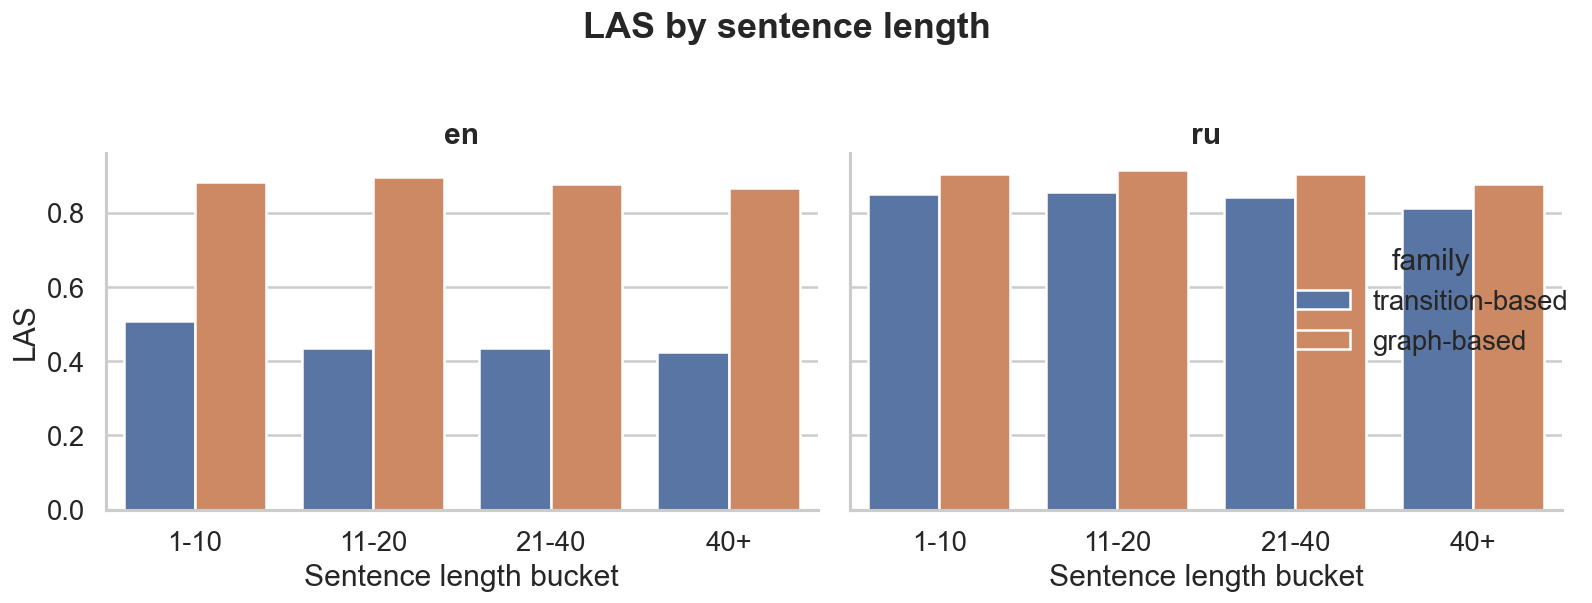

Saved fig_length.png


In [6]:
# Figure 3: LAS by sentence length bucket
ln = pd.read_csv("../results/accuracy_by_length.csv")
ln["family"] = ln["parser"].map(FAMILY)

g = sns.catplot(
    ln, x="bucket", y="las", hue="family", col="lang",
    kind="bar", order=["1-10", "11-20", "21-40", "40+"],
    height=5, aspect=1.1,
)
g.set_titles("{col_name}")
g.set_axis_labels("Sentence length bucket", "LAS")
g.figure.suptitle("LAS by sentence length", fontweight="bold", y=1.02)
g.figure.tight_layout()
g.figure.savefig(POSTER / "fig_length.png")
plt.show()
print("Saved fig_length.png")

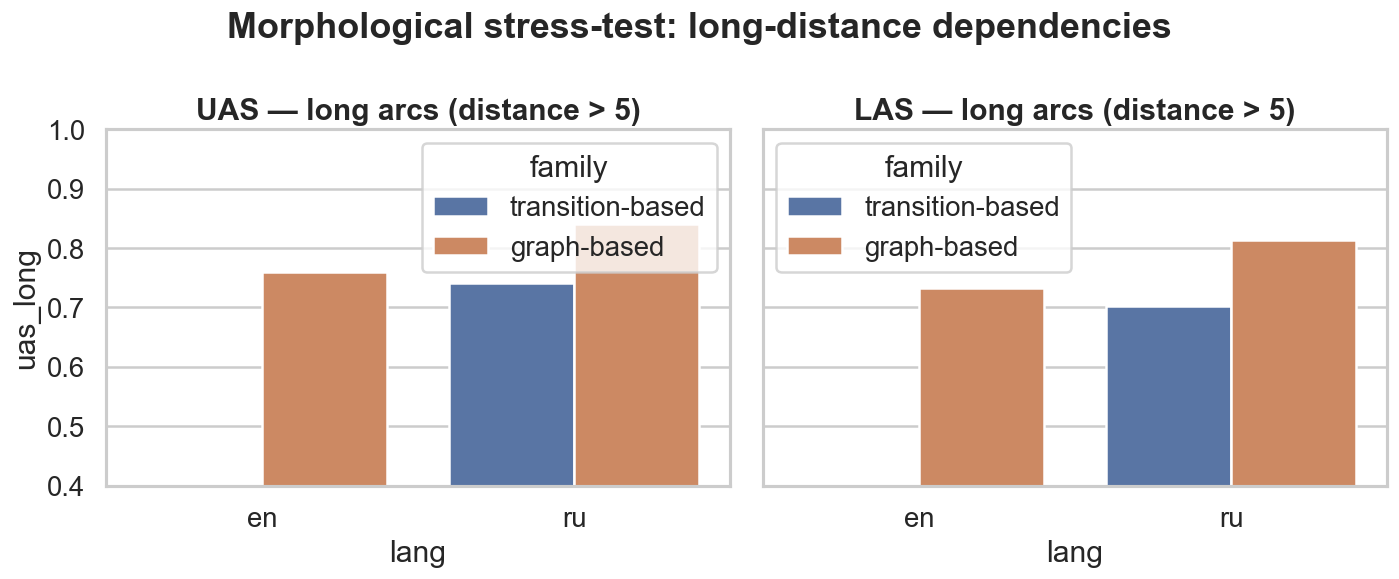

Saved fig_long_distance.png


In [7]:
# Figure 4: Long-distance arc stress-test
long = pd.read_csv("../results/long_distance_stress.csv")
long["family"] = long["parser"].map(FAMILY)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, metric, title in zip(axes, ["uas_long", "las_long"], ["UAS", "LAS"]):
    sns.barplot(long, x="lang", y=metric, hue="family", ax=ax)
    ax.set_title(f"{title} — long arcs (distance > 5)")
    ax.set_ylim(0.4, 1.0)

fig.suptitle("Morphological stress-test: long-distance dependencies", fontweight="bold")
fig.tight_layout()
fig.savefig(POSTER / "fig_long_distance.png")
plt.show()
print("Saved fig_long_distance.png")

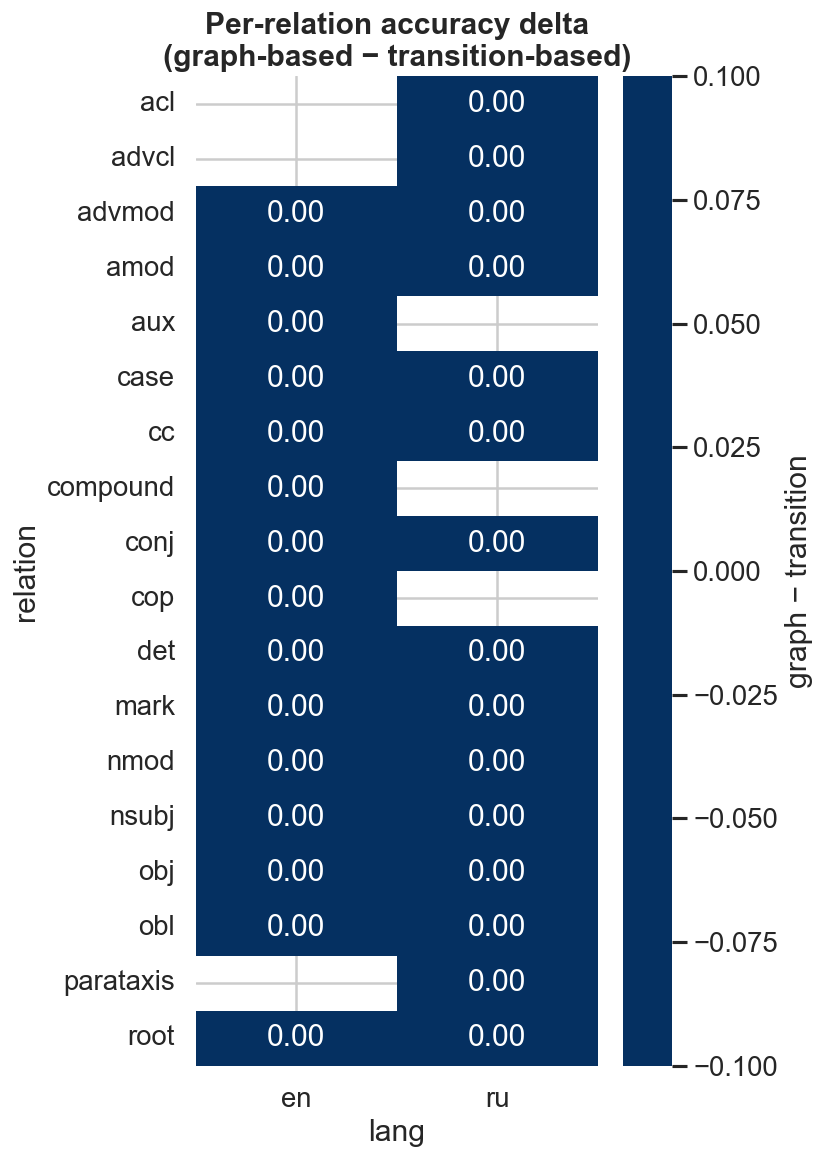

Saved fig_per_relation_delta.png


In [8]:
# Figure 5: Per-relation delta heatmap (graph-based − transition-based)
rel = pd.read_csv("../results/accuracy_by_relation.csv")
rel["family"] = rel["parser"].map(FAMILY)

# Keep top-15 relations by frequency per language
top = (
    rel.groupby(["lang", "relation"])["n"].sum()
    .reset_index()
    .sort_values(["lang", "n"], ascending=[True, False])
    .groupby("lang").head(15)
)
rel_top = rel.merge(top[["lang", "relation"]], on=["lang", "relation"])
pivot = rel_top.pivot_table(
    index=["lang", "relation"], columns="family", values="accuracy"
).reset_index()
pivot["delta"] = pivot.get("graph", 0) - pivot.get("transition", 0)
pivot_plot = pivot.pivot(index="relation", columns="lang", values="delta")

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(
    pivot_plot, annot=True, fmt=".2f",
    center=0, cmap="RdBu_r", ax=ax,
    cbar_kws={"label": "graph − transition"},
)
ax.set_title("Per-relation accuracy delta\n(graph-based − transition-based)", fontweight="bold")
fig.tight_layout()
fig.savefig(POSTER / "fig_per_relation_delta.png")
plt.show()
print("Saved fig_per_relation_delta.png")

## Figures saved to `poster/` (from this run)

Each PNG below is cited by number in `poster/poster.md`:

- `fig_accuracy.png` — **Figure 1.** UAS + LAS bars. Stanza dominates both metrics; spaCy EN LAS is visibly compressed by label-scheme mismatch.
- `fig_speed_vs_accuracy.png` — **Figure 2.** LAS vs tokens/sec (log x-axis). spaCy RU sits far-right at ~12k tok/s; Stanza sits top-centre on the accuracy axis. The trade-off is visually obvious.
- `fig_length.png` — **Figure 3.** LAS by bucket (1–10 / 11–20 / 21–40 / 40+). Both families degrade on long RU sentences; Stanza degrades more gracefully.
- `fig_long_distance.png` — **Figure 4.** UAS / LAS on arcs with distance > 5. EN UAS: 0.39 vs 0.76; RU UAS: 0.74 vs 0.84. The EN bar is visually dramatic; RU is where the size of the gap (vs aggregate) is the story.
- `fig_per_relation_delta.png` — **Figure 5.** Heatmap of (graph − transition) accuracy delta, top-15 relations per language. Red cells dominate the EN column (label-scheme effect); the RU column has genuine wins (`obl`, `flat`, `parataxis`, `compound`) and two visible blue cells (`xcomp`, `iobj`) where spaCy wins.

Run notebook 06 for the two additional figures — `fig_projectivity.png` and `fig_label_fairness.png`.
